# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# load model

In [3]:
model = joblib.load(
    "/kaggle/input/models/reemhatemzekry/stacking-model/keras/default/1/stacking_model.pkl"
)

# load Preprocessed Data

In [4]:
train_df = pd.read_csv(
    "/kaggle/input/datasets/reemhatemzekry/tinanic-preprocessed/processed_train.csv"
)

X = train_df.drop(
    "Survived",
    axis=1
)

y = train_df["Survived"]

# Predictions

In [5]:
preds = model.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Confusion Matrix

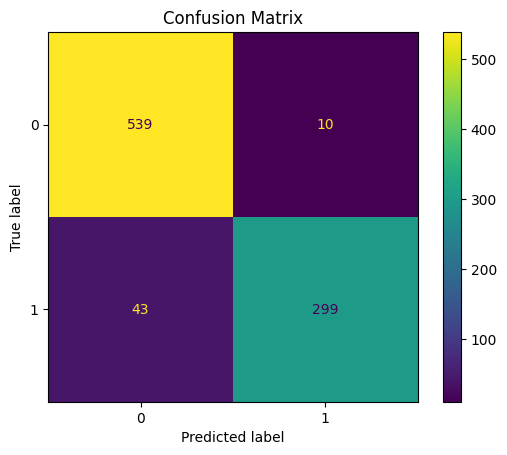

In [6]:
cm = confusion_matrix(y, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Classification report

In [7]:
print(classification_report(y, preds))

              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95       549
         1.0       0.97      0.87      0.92       342

    accuracy                           0.94       891
   macro avg       0.95      0.93      0.94       891
weighted avg       0.94      0.94      0.94       891



In [18]:
import joblib

stacking_pipeline = joblib.load("/kaggle/input/models/reemhatemzekry/stacking-model/keras/default/1/stacking_model.pkl")

probs = stacking_pipeline.predict_proba(X)[:, 1]
preds = stacking_pipeline.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# ROC Curve

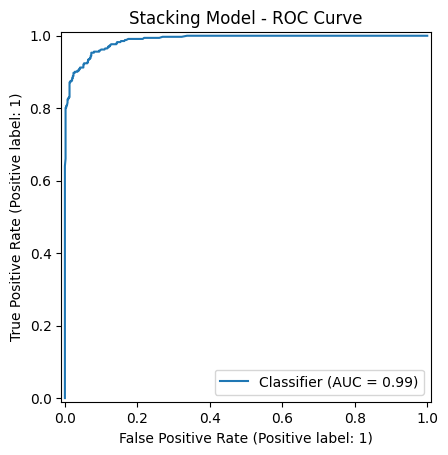

In [23]:
RocCurveDisplay.from_predictions(y, probs)

plt.title("Stacking Model - ROC Curve")
plt.show()

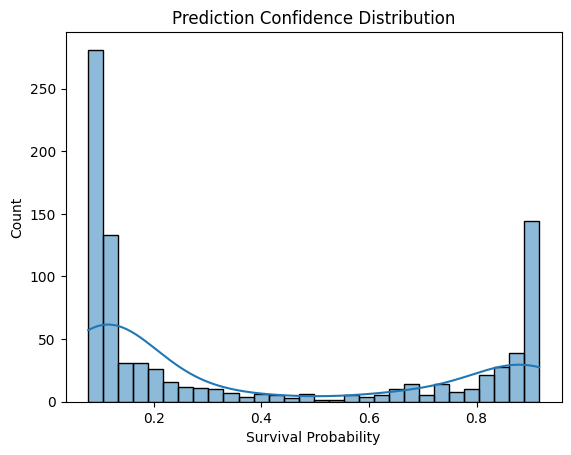

In [25]:
sns.histplot(probs, bins=30, kde=True)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Survival Probability")
plt.show()